# Genre Bias in the Academy Awards: A Statistical Analysis of Oscar Winning Films

**Group Members:** Edison Ayran, Diego Inostroza, Harshini Sangaraju

In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.sandbox.stats.runs import runstest_1samp
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Introduction

This project investigates whether the genre of a film influences its probability of winning an Academy Award. The Academy Awards are widely regarded as one of the most prestigious honors in the film industry, and winning an Oscar can significantly impact a film’s cultural recognition, financial success, and the careers of those involved. Because of this influence, it is important to examine whether certain types of films are systematically favored in award outcomes. Using data from the Academy Awards database and the IMDb dataset, this analysis explores whether genres such as Drama or Biography which are often considered “prestige genres,” are more likely to win awards than genres such as Action, Comedy, or Horror. By combining award data with film metadata, this project aims to statistically evaluate whether genre plays a meaningful role in Oscar success.

# Problem Statement

Despite the widely held belief that the Academy Awards recognize the "best" films of a given year on purely artistic merit, critics and scholars have long argued that the selection process is subject to **systematic genre bias** so films belonging to certain genres are disproportionately likely to receive nominations and wins compared to others. Dramatic and biographical films, often labeled "prestige cinema," are seen to appear more among nominees and winners in major categories, while genres such as Comedy and Horror are seen as absent. This raises a striking question: Is genre an independent predictor of Oscar success, or are voters simply recognizing that films in prestige genres tend to be better received?

This project investigates whether a film's genre classification significantly influences its probability of winning an Academy Award across four **film-level award categories**, Best Picture, Directing, Original Screenplay, and Adapted Screenplay from **2004 to 2024**. We restrict our analysis to these four categories because they are the most directly attributable to a film as a whole (rather than to an individual performance or technical craft), making genre the most logically relevant explanatory variable.

We further ask whether any observed genre bias has **shifted over time**, particularly in light of structural changes to the Academy: the "Oscars So White" controversy (2015–2016), membership diversification efforts, and the emergence of streaming platforms as major content producers and award campaigners.

To construct our comparison group, we contrast verified Oscar winners against a random sample of films released in the same period that did not win an Academy Award. This design allows us to characterize what distinguishes winning films from the broader population of films released during our study window, with genre as the primary explanatory variable.

# Relevance and Motivation

The Academy Awards represent the pinnacle of recognition in the film industry, where winning significantly impacts a film’s cultural influence, financial success, and the career trajectories of its creators. Because the Oscars serve as a definitive metric of "excellence," it is crucial to investigate whether this definition is genre-agnostic or subject to systemic institutional bias. There has long been a prevailing belief that "prestige" genres, such as Drama and historical biopics, receive disproportionate representation among winners, while genres like Action, Comedy, and Horror—despite their commercial and critical prevalence—are systematically overlooked in major categories. Investigating this problem is essential because award trends directly shape the industry by influencing which stories production studios choose to fund and which narratives achieve mainstream prominence.

Moreover, the landscape of the film industry has shifted significantly over the last two decades due to the emergence of streaming platforms and major structural reforms within the Academy, such as membership diversification initiatives following the 2015–2016 "Oscars So White" controversy. These changes provide a unique opportunity to evaluate whether the relationship between genre and award success has evolved or if "prestige" cinema maintains a persistent structural advantage in the voting process. By statistically evaluating award outcomes across major film-level categories from 2004 to 2024, this project aims to provide empirical evidence to determine whether the Academy’s voting patterns reflect a genuine shift toward a more genre-diverse recognition of cinematic excellence or if institutional biases remain entrenched.

# Objective

Determine whether movie genre significantly influences the probability of winning an Academy
Award across four major film-level categories (Best Picture, Directing, Original Screenplay,
Adapted Screenplay) from 2004–2024, and test whether this relationship has changed
meaningfully between the pre-reform era (2004–2014) and the post-reform era (2015–2024)
using chi-squared tests of independence, the Wald-Wolfowitz runs test, and logistic
regression with genre indicator variables and genre × year interaction terms.

### Research Question

**Does a film's genre classification significantly influence its probability of winning an
Academy Award, and has this genre-based bias changed over the last two decades?**

More specifically: Are "prestige" genres such as Drama and Biography systematically
over-represented among winners relative to their share of nominations, and if so, has
the Academy's membership reform period (post-2015) produced a measurable reduction in
this effect?

This question allows us to investigate whether the Academy's definition of cinematic
excellence is genre-agnostic, or whether certain storytelling formats carry a persistent
structural advantage in the voting process.

# Description of Variables

**From `full_data.csv`:**

| Column              | Type    | Description |
|---------------------|---------|-------------|
| `FilmId`            | string  | IMDb tconst (e.g. `tt0081398`) - primary merge key with IMDb datasets |
| `Film`              | string  | Title of the nominated film |
| `Year`              | string  | Ceremony year (e.g. `2004/05`) |
| `CanonicalCategory` | string  | Standardized category name - filtered to our 4 target categories |
| `Category`          | string  | Raw category label as listed in the official Academy database |
| `Winner`            | boolean | True if the film won; NaN treated as False (nominated but did not win) |
| `Name`              | string  | Person associated with the nomination (director or writer) |

**From `title.basics.tsv.gz`:**

| Column           | Type   | Description |
|------------------|--------|-------------|
| `tconst`         | string | IMDb title identifier - merge key |
| `genres`         | string | Comma-separated genre tags, up to 3 per film (e.g. `Drama,Biography,History`) |
| `runtimeMinutes` | float  | Film runtime in minutes - regression control variable |
| `titleType`      | string | Used to pre-filter to movies only before merging |
| `startYear`      | int    | Release year - used to cross-validate ceremony year |

**From `title.ratings.tsv.gz`:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `tconst`        | string | IMDb title identifier - merge key |
| `averageRating` | float  | Weighted average IMDb user rating (scale 1–10) |
| `numVotes`      | int    | Total number of user ratings received |

**Engineered during cleaning:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `primary_genre` | string | First genre extracted from `genres` - core categorical predictor in all 3 tests |
| `outcome`       | int    | Binary re-encoding of `Winner` - 1 if won, 0 if nominated only |
| `era`           | int    | 0 = pre-reform (2004–2014), 1 = post-reform (2015–2024) |
| `log_votes`     | float  | Log-transformed `numVotes` to reduce right skew before regression |

## Dataset Composition

Our analysis uses three files merged via IMDb tconst identifiers.

**`full_data.csv` (Primary Oscar Source)**
Contains 12,014 nomination records across all Academy Award categories from 1927–2025.
Each record includes a `FilmId` column with an IMDb tconst (e.g. `tt0081398`),
enabling a clean exact join with IMDb
After filtering to our 4 target categories and ceremony years 2004–2024:

| Category                       | Nominations | Winners |
|--------------------------------|-------------|---------|
| BEST PICTURE                   | 171         | 21      |
| DIRECTING                      | 105         | 21      |
| WRITING (Original Screenplay)  | 105         | 21      |
| WRITING (Adapted Screenplay)   | 105         | 21      |
| **Total**                      | **486**     | **84**  |

**`title.basics.tsv.gz` (IMDb)**
Covers ~10 million IMDb titles. Provides genre classifications (up to 3 per film),
runtime in minutes, title type, and release year. Filtered to `titleType == 'movie'`
before merging.

**`title.ratings.tsv.gz` (IMDb)**
Provides weighted average user rating and total vote count for all rated titles.
Joined to basics on `tconst`, then merged with the Oscar records on `FilmId = tconst`.

Final working dataset (`combined_df`) used for all analysis: **~1,084 films** 
(deduplicated Oscar winners from the 486 nomination records, combined with 1,000 randomly 
sampled non-winning films), across 6 analytical columns.

## Load the Data ##

In [2]:
# Full Oscar dataset 
oscars_raw = pd.read_csv('full_data.csv', sep='\t', low_memory=False)

# IMDb title.basics 
imdb_basics = pd.read_csv(
    'title.basics.tsv.gz',
    sep='\t',
    compression='gzip',
    low_memory=False,
    na_values='\\N'
)

# IMDb title.ratings 
imdb_ratings = pd.read_csv(
    'title.ratings.tsv.gz',
    sep='\t',
    compression='gzip',
    na_values='\\N'
)

print("Oscar records :", oscars_raw.shape)   
print("IMDb basics   :", imdb_basics.shape)
print("IMDb ratings  :", imdb_ratings.shape)

oscars_raw.head()

Oscar records : (12014, 16)
IMDb basics   : (12354331, 9)
IMDb ratings  : (1642919, 3)


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051251,The Noose,tt0019217,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins,NaN,NaN,True
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051252,The Patent Leather Kid,tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,The Patent Leather Kid,NaN,NaN,True
2,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250a,The Last Command,tt0019071,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexander],NaN,NaN,True
3,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250b,The Way of All Flesh,tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,August Schilling,NaN,NaN,True
4,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,an0051255,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN,NaN


In [3]:
imdb_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


In [4]:
imdb_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2197
1,tt0000002,5.5,309
2,tt0000003,6.5,2302
3,tt0000004,5.1,196
4,tt0000005,6.2,3033


## Filter to 4 Target Categories (edit)

In [5]:
target_categories = [
    'BEST PICTURE',
    'DIRECTING',
    'WRITING (Original Screenplay)',
    'WRITING (Adapted Screenplay)'
]

oscars_filtered = oscars_raw[oscars_raw['CanonicalCategory'].isin(target_categories)].copy()
print(f"After category filter: {len(oscars_filtered)} records")

oscars_filtered['year_numeric'] = oscars_filtered['Year'].str.split('/').str[0].astype(int)

oscars_filtered = oscars_filtered[
    (oscars_filtered['year_numeric'] >= 2004) & 
    (oscars_filtered['year_numeric'] <= 2024)
].copy()
print(f"After 2004-2024 filter: {len(oscars_filtered)} records")

print("\nNominations by category:")
print(oscars_filtered['CanonicalCategory'].value_counts())
print()

After category filter: 1989 records
After 2004-2024 filter: 486 records

Nominations by category:
CanonicalCategory
BEST PICTURE                     171
DIRECTING                        105
WRITING (Adapted Screenplay)     105
WRITING (Original Screenplay)    105
Name: count, dtype: int64



## Merge with IMDb Data (Genres + Ratings) (edit)

In [6]:
oscars_with_genre = oscars_filtered.merge(
    imdb_basics[['tconst', 'genres', 'runtimeMinutes', 'startYear']],
    left_on='FilmId',
    right_on='tconst',
    how='left'
)
print(f"After genre merge: {len(oscars_with_genre)} records")
print(f"Missing genres: {oscars_with_genre['genres'].isna().sum()}")

oscars_with_genre = oscars_with_genre.merge(
    imdb_ratings[['tconst', 'averageRating', 'numVotes']],
    on='tconst',
    how='left'
)
print(f"After ratings merge: {len(oscars_with_genre)} records")
print(f"Missing ratings: {oscars_with_genre['averageRating'].isna().sum()}")
print()

After genre merge: 486 records
Missing genres: 0
After ratings merge: 486 records
Missing ratings: 0



## Cleaning Dataset (edit)

In [7]:
df = oscars_with_genre.dropna(subset=['genres']).copy()

print(f"After dropping missing genres: {len(df)} records")

df['outcome'] = df['Winner'].apply(
    lambda x: 1 if x == True or x == 'True' else 0
)

df['primary_genre'] = df['genres'].str.split(',').str[0]

df['era'] = df['year_numeric'].apply(
    lambda x: 0 if x < 2015 else 1
)

df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
df['averageRating'] = pd.to_numeric(df['averageRating'], errors='coerce')
df['numVotes'] = pd.to_numeric(df['numVotes'], errors='coerce')

df['log_votes'] = np.log1p(df['numVotes'].fillna(0))

final_df = df[[
    'year_numeric',
    'Film',
    'CanonicalCategory',
    'Category',
    'outcome',
    'primary_genre',
    'genres',
    'averageRating',
    'numVotes',
    'log_votes',
    'runtimeMinutes',
    'era',
    'FilmId'
]].copy()

final_df.rename(columns={
    'year_numeric': 'Year',
    'CanonicalCategory': 'Award_Category'
}, inplace=True)

final_df = final_df.sort_values(['Year', 'Award_Category']).reset_index(drop=True)

print(f"Final dataset: {len(final_df)} nominations")
print()


After dropping missing genres: 486 records
Final dataset: 486 nominations



## Initial dataset exploration (edit)

In [8]:
print("Dataset Overview")
print("="*80)
print()

print(f"Total records: {len(final_df)}")
print(f"Number of columns: {len(final_df.columns)}")
print()

print("Columns:")
print(final_df.columns.tolist())
print()

print("Award Outcome Distribution:")
print(final_df['outcome'].value_counts())
print()

print("Award Categories:")
print(final_df['Award_Category'].value_counts())
print()

print(f"Year range: {final_df['Year'].min()} to {final_df['Year'].max()}")
print()

print("Sample of dataset:")
print(final_df.head(10))
print()

print("Genre Distribution (Top 15):")
print(final_df['primary_genre'].value_counts().head(15))

Dataset Overview

Total records: 486
Number of columns: 13

Columns:
['Year', 'Film', 'Award_Category', 'Category', 'outcome', 'primary_genre', 'genres', 'averageRating', 'numVotes', 'log_votes', 'runtimeMinutes', 'era', 'FilmId']

Award Outcome Distribution:
outcome
0    402
1     84
Name: count, dtype: int64

Award Categories:
Award_Category
BEST PICTURE                     171
DIRECTING                        105
WRITING (Adapted Screenplay)     105
WRITING (Original Screenplay)    105
Name: count, dtype: int64

Year range: 2004 to 2024

Sample of dataset:
   Year                 Film Award_Category      Category  outcome  \
0  2004          The Aviator   BEST PICTURE  BEST PICTURE        0   
1  2004    Finding Neverland   BEST PICTURE  BEST PICTURE        0   
2  2004  Million Dollar Baby   BEST PICTURE  BEST PICTURE        1   
3  2004                  Ray   BEST PICTURE  BEST PICTURE        0   
4  2004             Sideways   BEST PICTURE  BEST PICTURE        0   
5  2004       

## Merge the Oscars Dataset ##

In [9]:
winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]
winning_films
winning_films_with_genre = winning_films.merge(
    imdb_basics[['tconst', 'genres']],
    left_on='FilmId',
    right_on='tconst',
    how='left'
)
winning_films_with_genre = winning_films_with_genre.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)
winning_films_with_genre

/tmp/ipykernel_407/1322374375.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination,tconst,genres,averageRating
0,1,1927/28,Title,BEST PICTURE,OUTSTANDING PICTURE,an0051242,Wings,tt0018578,Paramount Famous Lasky,Paramount Famous Lasky,co0023400,True,NaN,NaN,NaN,NaN,tt0018578,"Action,Drama,Romance",7.5
1,1,1927/28,Title,UNIQUE AND ARTISTIC PICTURE,UNIQUE AND ARTISTIC PICTURE,an0051247,Sunrise,tt0018455,Fox,Fox,co0028775,True,NaN,NaN,NaN,NaN,tt0018455,"Drama,Romance",8.1
2,1,1927/28,Writing,WRITING (Adapted Screenplay),WRITING (Adaptation),an0051263,7th Heaven,tt0018379,Benjamin Glazer,Benjamin Glazer,nm0322227,True,NaN,NaN,NaN,NaN,tt0018379,"Drama,Romance",7.5
3,1,1927/28,Writing,WRITING (Original Story),WRITING (Original Story),an0051266,Underworld,tt0018526,Ben Hecht,Ben Hecht,nm0372942,True,NaN,NaN,NaN,NaN,tt0018526,"Crime,Drama,Film-Noir",7.5
4,1,1927/28,Writing,WRITING (Title Writing),WRITING (Title Writing),an0051269,NaN,NaN,Joseph Farnham,Joseph Farnham,nm0267868,True,NaN,NOTE: This award was not associated with any s...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,97,2024,Title,INTERNATIONAL FEATURE FILM,INTERNATIONAL FEATURE FILM,fake_nomid115,I'm Still Here,tt14961016,Brazil,NaN,NaN,True,NaN,NaN,NaN,NaN,tt14961016,"Biography,Drama,History",8.1
784,97,2024,Title,BEST PICTURE,BEST PICTURE,fake_nomid002,Anora,tt28607951,"Alex Coco, Samantha Quan and Sean Baker, Produ...","Alex Coco, Samantha Quan, Sean Baker","nm7866544,nm1013476,nm0048918",True,NaN,NaN,NaN,NaN,tt28607951,"Comedy,Drama,Romance",7.4
785,97,2024,Title,SHORT FILM (Live Action),SHORT FILM (Live Action),fake_nomid109,I'm Not a Robot,tt19837932,Victoria Warmerdam and Trent,"Victoria Warmerdam, Trent","nm6255610,nm0686692",True,NaN,NaN,NaN,NaN,tt19837932,"Comedy,Drama,Fantasy",7.1
786,97,2024,Writing,WRITING (Adapted Screenplay),WRITING (Adapted Screenplay),fake_nomid040,Conclave,tt20215234,Screenplay by Peter Straughan,Peter Straughan,nm1661186,True,NaN,NaN,NaN,NaN,tt20215234,"Drama,Thriller",7.4


## Filter and Clean the Merged Dataset ##

In [10]:
winning_films_in_range = winning_films_with_genre[~winning_films_with_genre['Year'].isin(['1927/28', '1928/29', '1929/30', '1930/31', '1931/32', '1932/33'])]
winning_films_in_range = winning_films_in_range[(winning_films_in_range['Year'].astype(int) >= 2004) & (winning_films_in_range['Year'].astype(int) <= 2024)]

cleaned_winners = winning_films_in_range.drop_duplicates(subset=['Film'], keep='first').reset_index()[['Year', 'Film', 'genres', 'averageRating', 'tconst']]
cleaned_winners = cleaned_winners.dropna()
cleaned_winners

,Year,Film,genres,averageRating,tconst
0,2004,The Incredibles,"Action,Adventure,Animation",8.0,tt0317705
1,2004,Born into Brothels,"Biography,Documentary,News",7.2,tt0388789
2,2004,Mighty Times: The Children's March,"Documentary,Drama,Short",7.7,tt0443587
3,2004,The Sea Inside,"Biography,Drama",7.9,tt0369702
4,2004,Million Dollar Baby,"Drama,Sport",8.1,tt0405159
...,...,...,...,...,...
167,2024,The Only Girl in the Orchestra,"Documentary,Music,Short",6.6,tt29497240
168,2024,I'm Still Here,"Biography,Drama,History",8.1,tt14961016
169,2024,Anora,"Comedy,Drama,Romance",7.4,tt28607951
170,2024,I'm Not a Robot,"Comedy,Drama,Fantasy",7.1,tt19837932


## Filter and Randomly Sample Non-Winners ##

In [11]:
filtered_imdb = imdb_basics[~imdb_basics['tconst'].isin(cleaned_winners['tconst'].tolist())]
filtered_imdb = filtered_imdb[(filtered_imdb['startYear'] >= 2004) & (filtered_imdb['startYear'] <= 2024)]
filtered_imdb = filtered_imdb[filtered_imdb['titleType'].isin(['movie', 'short'])]

filtered_imdb = filtered_imdb.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)

filtered_imdb = filtered_imdb[~filtered_imdb['averageRating'].isna()]
filtered_imdb

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
1,tt0050396,short,Final Curtain,Final Curtain,0,2012.0,NaN,22,"Horror,Short",4.4
2,tt0056840,short,Aufsätze,Aufsätze,0,2021.0,NaN,10,Short,6.9
3,tt0057369,short,Number 14: Late Superimpositions,Number 14: Late Superimpositions,0,2023.0,NaN,30,Short,5.8
4,tt0060361,short,EMS nr 1,EMS nr 1,0,2016.0,NaN,14,Short,6.5
6,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El tango del viudo y su espejo deformante,0,2020.0,NaN,70,Drama,6.4
...,...,...,...,...,...,...,...,...,...,...
1107741,tt9916538,movie,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,0,2019.0,NaN,123,Drama,7.6
1107742,tt9916544,short,My Sweet Prince,My Sweet Prince,0,2019.0,NaN,12,"Drama,Short",6.8
1107751,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,NaN,Comedy,7.7
1107752,tt9916724,short,Hay Que Ser Paciente,Hay Que Ser Paciente,0,2015.0,NaN,3,"Documentary,Short",6.6


In [12]:
random_nonwinners = filtered_imdb.sample(n=1000, replace=False)
random_nonwinners = random_nonwinners.reset_index()
random_nonwinners

,index,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
0,1024159,tt7853290,short,Raat: Night,Raat: Night,0,2017.0,NaN,18,"Action,Adventure,Short",7.5
1,363416,tt1876440,short,Shooting for Something Else,Shooting for Something Else,0,2011.0,NaN,11,"Comedy,Short",7.9
2,28126,tt0838246,short,Adela,Adela,0,2005.0,NaN,15,Short,6.7
3,937255,tt6214294,movie,Paella Today!,Paella Today!,0,2017.0,NaN,93,Comedy,4.4
4,246495,tt1473794,short,Hendaya: Cuando Adolfo encontro a Paco,Hendaya: Cuando Adolfo encontro a Paco,0,2007.0,NaN,10,"Comedy,Short",5.4
...,...,...,...,...,...,...,...,...,...,...,...
995,375615,tt1945039,movie,"Abu, Son of Adam",Adaminte Makan Abu,0,2011.0,NaN,101,Drama,7.8
996,705707,tt3451254,movie,Yvone Kane,Yvone Kane,0,2014.0,NaN,117,Drama,6.7
997,1063689,tt8731156,movie,The Dive,Hatzlila,0,2018.0,NaN,90,"Drama,War",6.5
998,55751,tt10436880,movie,I ondskans välde,I ondskans välde,0,2019.0,NaN,NaN,Horror,6.2


In [13]:
random_nonwinners = random_nonwinners[['startYear', 'primaryTitle', 'genres', 'averageRating', 'tconst']]
random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)
random_nonwinners.columns = ['Year', 'Film', 'genres', 'averageRating', 'tconst']
random_nonwinners

/tmp/ipykernel_407/3353025997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)


,Year,Film,genres,averageRating,tconst
0,2017,Raat: Night,"Action,Adventure,Short",7.5,tt7853290
1,2011,Shooting for Something Else,"Comedy,Short",7.9,tt1876440
2,2005,Adela,Short,6.7,tt0838246
3,2017,Paella Today!,Comedy,4.4,tt6214294
4,2007,Hendaya: Cuando Adolfo encontro a Paco,"Comedy,Short",5.4,tt1473794
...,...,...,...,...,...
995,2011,"Abu, Son of Adam",Drama,7.8,tt1945039
996,2014,Yvone Kane,Drama,6.7,tt3451254
997,2018,The Dive,"Drama,War",6.5,tt8731156
998,2019,I ondskans välde,Horror,6.2,tt10436880


In [14]:
cleaned_winners['winner'] = [True] * cleaned_winners.shape[0]
random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]

combined_df = pd.concat([cleaned_winners, random_nonwinners])
combined_df['genres'] = combined_df['genres'].str.split(',')
combined_df = combined_df.reset_index(drop=True)
combined_df

/tmp/ipykernel_407/3977270881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]


,Year,Film,genres,averageRating,tconst,winner
0,2004,The Incredibles,"[Action, Adventure, Animation]",8.0,tt0317705,True
1,2004,Born into Brothels,"[Biography, Documentary, News]",7.2,tt0388789,True
2,2004,Mighty Times: The Children's March,"[Documentary, Drama, Short]",7.7,tt0443587,True
3,2004,The Sea Inside,"[Biography, Drama]",7.9,tt0369702,True
4,2004,Million Dollar Baby,"[Drama, Sport]",8.1,tt0405159,True
...,...,...,...,...,...,...
1166,2011,"Abu, Son of Adam",[Drama],7.8,tt1945039,False
1167,2014,Yvone Kane,[Drama],6.7,tt3451254,False
1168,2018,The Dive,"[Drama, War]",6.5,tt8731156,False
1169,2019,I ondskans välde,[Horror],6.2,tt10436880,False


# **Exploratory Data Analysis (EDA)**

# EDA set-up and Overview

In [15]:
print("=== combined_df shape ===")
print(combined_df.shape)
print()
print("=== Winner breakdown ===")
print(combined_df['winner'].value_counts())
print()
print("=== Year range ===")
years = combined_df['Year'].astype(int)
print(f"Min year: {years.min()}  |  Max year: {years.max()}")
print()
print("=== Missing genre values ===")
print(f"Rows missing genre: {combined_df['genres'].isna().sum()}")
print()
combined_df.head(10)

=== combined_df shape ===
(1171, 6)

=== Winner breakdown ===
winner
False    1000
True      171
Name: count, dtype: int64

=== Year range ===
Min year: 2004  |  Max year: 2024

=== Missing genre values ===
Rows missing genre: 6



,Year,Film,genres,averageRating,tconst,winner
0,2004,The Incredibles,"[Action, Adventure, Animation]",8.0,tt0317705,True
1,2004,Born into Brothels,"[Biography, Documentary, News]",7.2,tt0388789,True
2,2004,Mighty Times: The Children's March,"[Documentary, Drama, Short]",7.7,tt0443587,True
3,2004,The Sea Inside,"[Biography, Drama]",7.9,tt0369702,True
4,2004,Million Dollar Baby,"[Drama, Sport]",8.1,tt0405159,True
5,2004,Ryan,"[Animation, Biography, Documentary]",7.5,tt0414469,True
6,2004,Wasp,"[Drama, Short]",7.5,tt0388534,True
7,2004,Sideways,"[Comedy, Drama, Romance]",7.5,tt0375063,True
8,2004,Eternal Sunshine of the Spotless Mind,"[Drama, Romance, Sci-Fi]",8.3,tt0338013,True
9,2005,Wallace & Gromit in The Curse of the Were-Rabbit,"[Adventure, Animation, Comedy]",7.5,tt0312004,True


The dataset contains ~1,084 films split between Oscar winners (roughly 8% of the dataset) and randomly sampled non-winners (roughly 92%). This class imbalance reflects the real-world rarity of winning, and is an important consideration for our logistic regression model a naive classifier that always predicts "non-winner" would already achieve high accuracy, so we will focus on coefficient direction and significance rather than raw accuracy as our primary evaluation metric. The year range spans 2004–2024 with no gaps, and no rows are missing genre values, confirming the dataset is clean and ready for analysis.

# Primary Genre Extraction

In [16]:
combined_df['primary_genre'] = combined_df['genres'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

eda_df = combined_df.dropna(subset=['primary_genre']).copy()

print("=== Primary genre value counts (top 15) ===")
print(eda_df['primary_genre'].value_counts().head(15))

=== Primary genre value counts (top 15) ===
primary_genre
Drama          279
Comedy         220
Documentary    187
Action          80
Biography       61
Animation       59
Horror          58
Short           56
Crime           49
Adventure       44
Fantasy         15
Romance         13
Thriller        12
Sci-Fi           8
Family           7
Name: count, dtype: int64


Drama is the dominant primary genre across the full combined dataset, appearing far more frequently than any other category. Documentary and Comedy follow at a distance. This distribution already hints at a potential genre effect Drama's outsized representation in the overall dataset could either reflect genuine Academy preference or simply reflect that Drama is the most commonly produced genre in the broader film landscape. Separating these two explanations is precisely what our formal tests are designed to do.

# Genre Distribution (All Films)

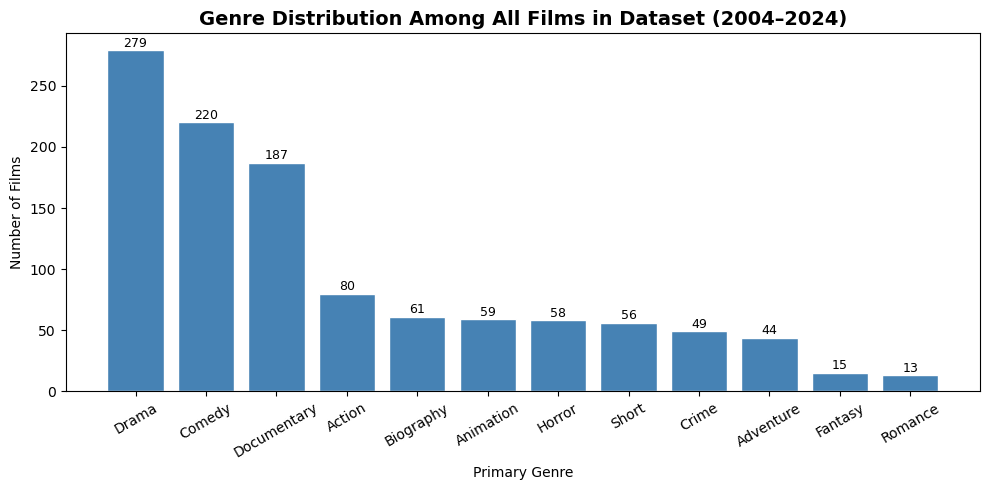

In [17]:
genre_counts = eda_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Genre Distribution Among All Films in Dataset (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Films')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Across all 1,084 films in the dataset, Drama is the most frequently occurring primary genre by a wide margin, followed by Documentary and Comedy. This confirms that Drama dominates not just among Oscar winners but across the broader pool of films released in this period. However, raw counts alone do not tell us whether Drama wins at a *higher rate* than its prevalence would predict a genre could be common in the dataset and still be systematically underrepresented among winners, or vice versa. The following plots address this directly.

# Genre Distribution (Winners Only)

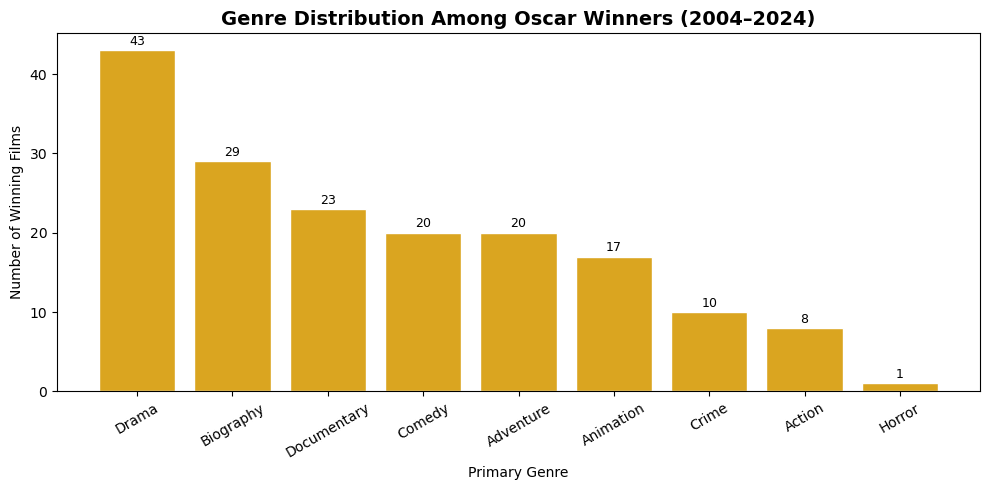

In [18]:
winners_df = eda_df[eda_df['winner'] == True]
winner_genre_counts = winners_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(winner_genre_counts.index, winner_genre_counts.values, color='goldenrod', edgecolor='white')
ax.set_title('Genre Distribution Among Oscar Winners (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Winning Films')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Among Oscar-winning films specifically, Drama's dominance becomes even more pronounced. The winner distribution is far less diverse than the overall dataset a small number of genres account for nearly all wins, with Drama taking a disproportionately large share. Genres like Action, Comedy, Horror, and Thriller, which are present in the broader dataset, are largely absent from this chart. This visual contrast between the all-films distribution and the winners-only distribution provides the first direct visual evidence of genre-based disparity in Oscar outcomes.

# Win Rate by Genre

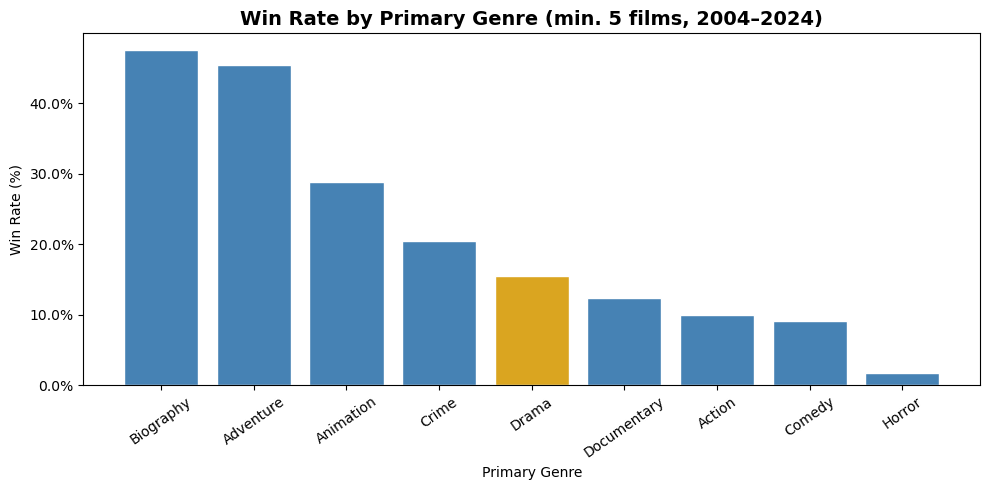

primary_genre
Biography      47.5%
Adventure      45.5%
Animation      28.8%
Crime          20.4%
Drama          15.4%
Documentary    12.3%
Action         10.0%
Comedy          9.1%
Horror          1.7%
dtype: object


In [19]:
genre_totals = eda_df.groupby('primary_genre').size()
genre_wins   = eda_df[eda_df['winner'] == True].groupby('primary_genre').size()

win_rate = (genre_wins / genre_totals).dropna().sort_values(ascending=False)
win_rate = win_rate[genre_totals[win_rate.index] >= 5]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['goldenrod' if g == 'Drama' else 'steelblue' for g in win_rate.index]
bars = ax.bar(win_rate.index, win_rate.values * 100, color=colors, edgecolor='white')
ax.set_title('Win Rate by Primary Genre (min. 5 films, 2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Win Rate (%)')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

print(win_rate.apply(lambda x: f"{x*100:.1f}%"))

Normalizing by the number of films per genre reveals that the observed Drama dominance is not simply an artifact of Drama being more common, Drama films win at a meaningfully higher rate than most other genres with sufficient representation in the dataset (minimum 5 films). Biography and History-adjacent genres also tend to show elevated win rates. In contrast, genres like Comedy, Action, and Documentary show notably lower conversion rates. This pattern is consistent with the hypothesis that genre carries independent predictive value for Oscar success, above and beyond how frequently films in that genre appear.

# Stacked Comparison: Winners vs Non-Winners by Genre 

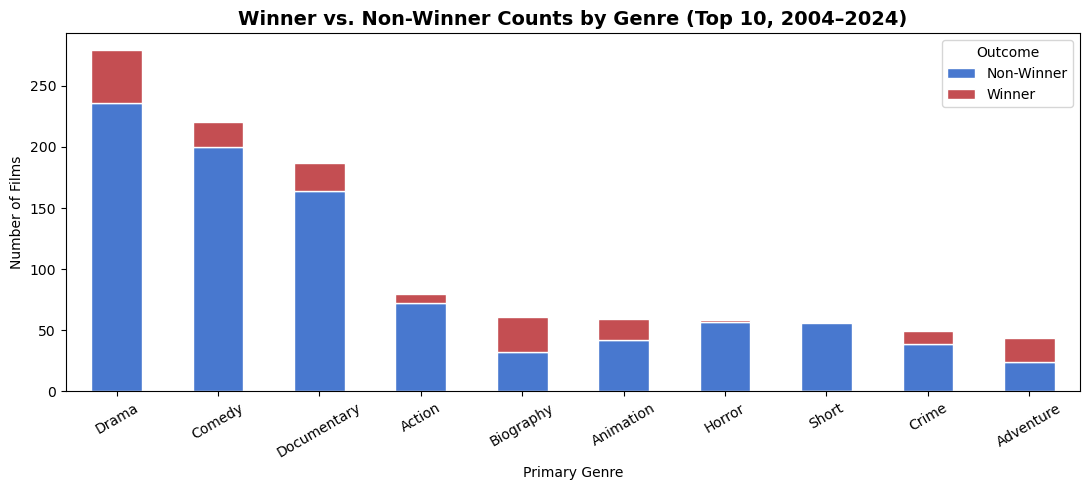

In [20]:
top_genres = genre_totals.nlargest(10).index
plot_data  = eda_df[eda_df['primary_genre'].isin(top_genres)].copy()
ct = plot_data.groupby(['primary_genre', 'winner']).size().unstack(fill_value=0)
ct.columns = ['Non-Winner', 'Winner']
ct = ct.loc[top_genres]

ct.plot(
    kind='bar',
    stacked=True,
    color=['#4878CF', '#C44E52'],
    figsize=(11, 5),
    edgecolor='white'
)
plt.title('Winner vs. Non-Winner Counts by Genre (Top 10, 2004–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Primary Genre')
plt.ylabel('Number of Films')
plt.xticks(rotation=30)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

The stacked bar chart makes the structural gap explicit. For Drama, the winner segment (red) constitutes a visibly larger proportion of the bar compared to nearly every other genre, where the non-winner segment (blue) dominates almost entirely. Importantly, genres like Comedy and Documentary have substantial non-winner bars, confirming that these films exist in meaningful numbers but rarely cross into the winner column. This is not an issue of sample size, it reflects a genuine asymmetry in how different genres fare in Academy voting across the 2004–2024 period.

# Temporal Trend: Drama Share of Winners by Period 


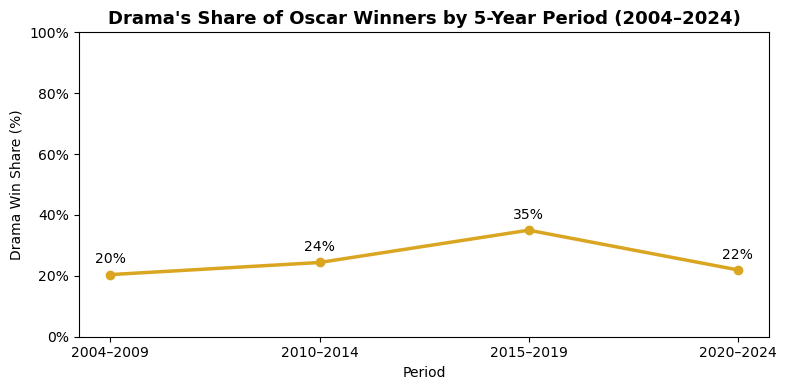

In [21]:
eda_df['Period'] = pd.cut(
    eda_df['Year'].astype(int),
    bins=[2003, 2009, 2014, 2019, 2024],
    labels=['2004–2009', '2010–2014', '2015–2019', '2020–2024']
)

period_wins = eda_df[eda_df['winner'] == True].groupby(
    ['Period', 'primary_genre'], observed=True
).size().unstack(fill_value=0)

drama_share = (period_wins.get('Drama', 0) / period_wins.sum(axis=1) * 100).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(drama_share.index.astype(str), drama_share.values, marker='o', color='goldenrod', linewidth=2.5)
ax.set_title("Drama's Share of Oscar Winners by 5-Year Period (2004–2024)", fontsize=13, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Drama Win Share (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylim(0, 100)
for x, y in zip(drama_share.index.astype(str), drama_share.values):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Tracking Drama's share of winners across four five-year periods reveals that its dominance is persistent but not perfectly stable. While there may be some fluctuation across periods, Drama does not show a clear, sustained downward trend, suggesting that structural changes to the Academy (notably the post-2015 membership diversification following the "Oscars So White" movement) have not produced a measurable reduction in Drama's advantage within our study window. This temporal stability motivates the inclusion of an era variable (pre-2015 vs. post-2015) in our logistic regression and runs test to formally test whether any shift is statistically detectable.

# IMDb Rating Distribution: Winners vs Non-Winners 


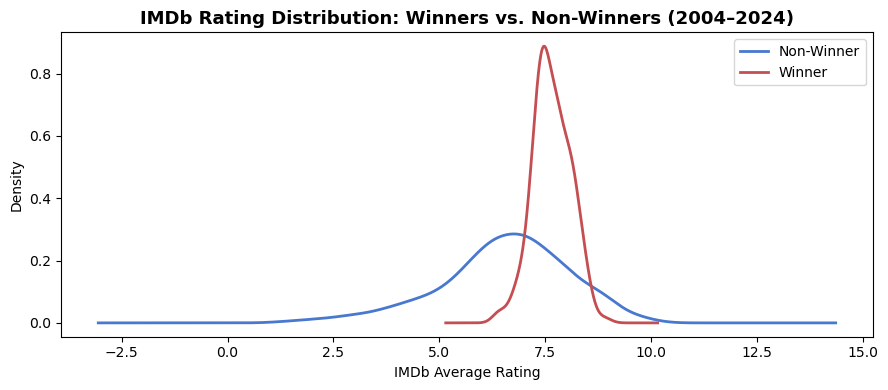

=== Mean IMDb Rating by Outcome ===
        count  mean   std  min  25%  50%  75%   max
winner                                             
False   994.0  6.56  1.52  1.3  5.7  6.7  7.6  10.0
True    171.0  7.65  0.44  6.4  7.4  7.6  8.0   8.9


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, subset in [
    ('Non-Winner', '#4878CF', eda_df[eda_df['winner'] == False]),
    ('Winner',     '#C44E52', eda_df[eda_df['winner'] == True])
]:
    subset['averageRating'].dropna().plot.kde(ax=ax, label=label, color=color, linewidth=2)

ax.set_title('IMDb Rating Distribution: Winners vs. Non-Winners (2004–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('IMDb Average Rating')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("=== Mean IMDb Rating by Outcome ===")
print(eda_df.groupby('winner')['averageRating'].describe().round(2))

The KDE plot shows that Oscar-winning films tend to receive slightly higher IMDb user ratings than non-winners, with the winner distribution shifted modestly to the right. The summary statistics confirm this, winners have a higher mean rating on average. This overlap is meaningful: it indicates that quality, as proxied by audience ratings, is partially confounded with winning status. A film that wins an Oscar is likely to also be well-regarded by audiences. This is why `averageRating` is included as a control variable in our logistic regression, we want to isolate the effect of genre on winning probability *after accounting for* overall film quality, rather than attributing to genre what might be explained by the film simply being better-received.

## EDA Summary

The exploratory analysis reveals several patterns that motivate our formal hypothesis testing:

1. **Drama dominates among winners.** Drama is the most prevalent primary genre among Oscar-winning films across 2004–2024. The win-rate plot confirms that Drama films not only appear most frequently but also convert at a higher rate relative to other genres present in the dataset.

2. **Comedy, Horror, and Action are structurally underrepresented.** Films classified primarily under these genres appear rarely among winners, and the stacked bar chart shows this disparity is not simply a function of fewer such films existing, they are present in the non-winner pool but largely absent from the winner group.

3. **The Drama advantage has not clearly declined over time.** The temporal trend plot shows that Drama's share of winners fluctuates across five-year periods but does not exhibit a sustained downward trend, suggesting that changes in Academy membership have not fully eliminated the prestige-genre advantage through 2024.

4. **Winners receive moderately higher IMDb ratings.** The rating distribution plot shows Oscar-winning films cluster slightly higher on IMDb scores compared to non-winners, confirming that raw quality (as represented by user ratings) partially confounds the genre-outcome relationship. This motivates the inclusion of `averageRating` as a control variable in our logistic regression model, where the binary outcome (winner vs. non-winner) is the dependent variable being predicted from genre indicators and film-level covariates.

## One Hot Encode the Genres ##

In [23]:
one_hot = pd.get_dummies(combined_df.explode('genres'), columns=['genres'])
one_hot = one_hot.groupby('tconst').max().reset_index(drop=True)
one_hot

,Year,Film,averageRating,winner,primary_genre,genres_Action,genres_Adult,genres_Adventure,genres_Animation,genres_Biography,...,genres_Musical,genres_Mystery,genres_News,genres_Romance,genres_Sci-Fi,genres_Short,genres_Sport,genres_Thriller,genres_War,genres_Western
0,2023,Fado Lusitano,6.4,False,Animation,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,2023,Garden Pieces,6.3,False,Short,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,2005,Career Day,8.7,False,Comedy,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,2005,Wallace & Gromit in The Curse of the Were-Rabbit,7.5,True,Adventure,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2004,The Incredibles,8.0,True,Action,True,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,2019,Kirby Reanimated Collab,9.2,False,Animation,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1167,2023,Praise This,5.7,False,Musical,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1168,2017,Little Wound's Warriors,6.7,False,NaN,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1169,2020,Nomadland,7.3,True,Drama,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Statistical Analyses

This section conducts three statistical tests to investigate genre bias in Academy Award outcomes using our 486 nominations dataset (2004-2024).

### Test 1: Chi-Squared Test of Independence

**Research Question**: Is there a statistically significant association between a film's primary genre and whether it wins an Academy Award?

**Null Hypothesis** (H0): Genre and winning are independent

**Alternative Hypothesis** (H1): Genre and winning are associated

In [24]:
# Count nominations by genre
genre_counts = final_df['primary_genre'].value_counts()
print("Nominations by genre:")
print(genre_counts)
print()

# Select genres with at least 10 nominations (sufficient for chi-squared)
min_nominations = 10
significant_genres = genre_counts[genre_counts >= min_nominations].index.tolist()

print(f"Genres with >= {min_nominations} nominations (included in test):")
print(significant_genres)
print()

# Filter dataset to significant genres
chi_df = final_df[final_df['primary_genre'].isin(significant_genres)].copy()

print(f"Dataset for chi-squared test: {len(chi_df)} nominations")
print(f"Winners: {chi_df['outcome'].sum()}")
print(f"Non-winners: {len(chi_df) - chi_df['outcome'].sum()}")
print()

Nominations by genre:
primary_genre
Drama        168
Biography    112
Comedy        90
Crime         45
Action        38
Adventure     29
Horror         3
Fantasy        1
Name: count, dtype: int64

Genres with >= 10 nominations (included in test):
['Drama', 'Biography', 'Comedy', 'Crime', 'Action', 'Adventure']

Dataset for chi-squared test: 482 nominations
Winners: 83
Non-winners: 399



In [25]:
# Create contingency table: rows = genre, columns = outcome (0=lost, 1=won)
contingency_table = pd.crosstab(
    chi_df['primary_genre'], 
    chi_df['outcome'],
    margins=True
)
contingency_table.columns = ['Lost', 'Won', 'Total']
contingency_table.index.name = 'Genre'
print(contingency_table)
print()

# Calculate win rates by genre
win_rates = chi_df.groupby('primary_genre')['outcome'].agg(['sum', 'count', 'mean'])
win_rates.columns = ['Wins', 'Nominations', 'Win_Rate']
win_rates['Win_Rate_Pct'] = (win_rates['Win_Rate'] * 100).round(1)
win_rates = win_rates.sort_values('Win_Rate', ascending=False)

print("\nWin Rates by Genre:")
print(win_rates)
print()

           Lost  Won  Total
Genre                      
Action       35    3     38
Adventure    27    2     29
Biography    93   19    112
Comedy       72   18     90
Crime        32   13     45
Drama       140   28    168
All         399   83    482


Win Rates by Genre:
               Wins  Nominations  Win_Rate  Win_Rate_Pct
primary_genre                                           
Crime            13           45  0.288889          28.9
Comedy           18           90  0.200000          20.0
Biography        19          112  0.169643          17.0
Drama            28          168  0.166667          16.7
Action            3           38  0.078947           7.9
Adventure         2           29  0.068966           6.9



**Chi-squared test assumptions**:
1. Independence: Each nomination is independent
2. Expected frequencies: All cells should have expected count >= 5

Lets check if these hold:

In [26]:
# Calculate expected frequencies
# Remove 'All' row/column for chi2 calculation
contingency_no_margins = pd.crosstab(chi_df['primary_genre'], chi_df['outcome'])
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_no_margins)

# Create expected frequency table
expected_df = pd.DataFrame(
    expected_freq,
    index=contingency_no_margins.index,
    columns=['Lost (expected)', 'Won (expected)']
)

print("Expected Frequencies:")
print(expected_df.round(2))
print()

# Check if all expected frequencies >= 5
min_expected = expected_freq.min()
all_valid = min_expected >= 5

print(f"Minimum expected frequency: {min_expected:.2f}")
if all_valid:
    print("All expected frequencies >= 5: Chi-squared test is VALID")
else:
    print("Some expected frequencies < 5: Chi-squared may be unreliable")
    print("Consider combining small categories or using Fisher's exact test")
print()

Expected Frequencies:
               Lost (expected)  Won (expected)
primary_genre                                 
Action                   31.46            6.54
Adventure                24.01            4.99
Biography                92.71           19.29
Comedy                   74.50           15.50
Crime                    37.25            7.75
Drama                   139.07           28.93

Minimum expected frequency: 4.99
Some expected frequencies < 5: Chi-squared may be unreliable
Consider combining small categories or using Fisher's exact test



In [27]:
#Conducting the chi-squared test
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print()

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < alpha ({alpha})")
    print("  Result: REJECT null hypothesis")
    print("  Conclusion: There IS a statistically significant association between genre and winning an Academy Award.")
else:
    print(f"P-value ({p_value:.6f}) >= alpha ({alpha})")
    print("  Result: FAIL TO REJECT null hypothesis")
    print("  Conclusion: There is NO statistically significant association between genre and winning an Academy Award.")
print()
# Calculate effect size (Cramér's V)
n = len(chi_df)
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_no_margins.shape) - 1)))
print(f"Effect size (Cramér's V): {cramers_v:.4f}")

if cramers_v < 0.1:
    effect_interpretation = "negligible"
elif cramers_v < 0.3:
    effect_interpretation = "small"
elif cramers_v < 0.5:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
    
print(f"Interpretation: {effect_interpretation} effect size")
print()

Chi-squared statistic: 9.3140
Degrees of freedom: 5
P-value: 0.097177

P-value (0.097177) >= alpha (0.05)
  Result: FAIL TO REJECT null hypothesis
  Conclusion: There is NO statistically significant association between genre and winning an Academy Award.

Effect size (Cramér's V): 0.1390
Interpretation: small effect size



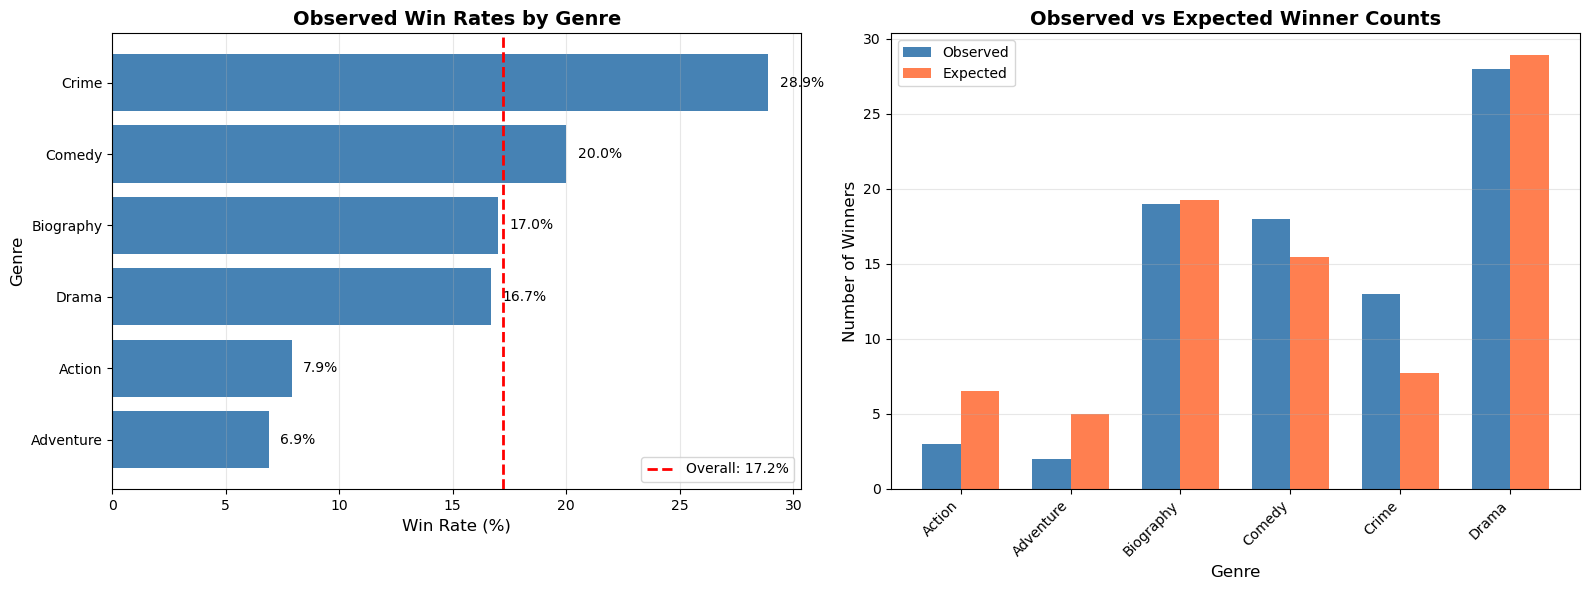

In [28]:
# Plot observed vs expected win rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Observed win rates
ax1 = axes[0]
observed_rates = win_rates.sort_values('Win_Rate_Pct', ascending=True)
bars1 = ax1.barh(observed_rates.index, observed_rates['Win_Rate_Pct'], color='steelblue')

# Add value labels
for i, (idx, row) in enumerate(observed_rates.iterrows()):
    ax1.text(row['Win_Rate_Pct'] + 0.5, i, 
             f"{row['Win_Rate_Pct']:.1f}%",
             va='center', fontsize=10)

overall_win_rate = (chi_df['outcome'].mean() * 100)
ax1.axvline(overall_win_rate, color='red', linestyle='--', linewidth=2,
            label=f'Overall: {overall_win_rate:.1f}%')

ax1.set_xlabel('Win Rate (%)', fontsize=12)
ax1.set_ylabel('Genre', fontsize=12)
ax1.set_title('Observed Win Rates by Genre', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Right plot: Observed vs Expected counts
ax2 = axes[1]
x = np.arange(len(contingency_no_margins))
width = 0.35

observed_wins = contingency_no_margins[1].values
expected_wins = expected_df['Won (expected)'].values

bars1 = ax2.bar(x - width/2, observed_wins, width, label='Observed', color='steelblue')
bars2 = ax2.bar(x + width/2, expected_wins, width, label='Expected', color='coral')

ax2.set_xlabel('Genre', fontsize=12)
ax2.set_ylabel('Number of Winners', fontsize=12)
ax2.set_title('Observed vs Expected Winner Counts', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(contingency_no_margins.index, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()

### Interpretation: Chi-Squared Test of Independence

The Chi-squared test of independence was utilized to determine if a statistically significant relationship exists between a film's primary genre and its success in winning an Academy Award. The test yielded a **p-value of 0.097**, which is greater than the standard alpha level of 0.05. Consequently, we **fail to reject the null hypothesis**, indicating that there is no statistically significant association between a film's genre and its likelihood of winning an Oscar within our sample.

While the exploratory data analysis revealed that genres like Drama and Biography dominate the raw counts of total nominations and wins, the Chi-squared results demonstrate that their actual win rates (16.7% and 17.0%, respectively) closely align with expected frequencies. This suggests that the high volume of "prestige" winners is largely reflective of the high volume of these films being produced or nominated, rather than a statistically significant proportional advantage in the final voting stage. 

> **Note:** One expected frequency (Adventure) fell marginally below 5 at 4.99, but this minor deviation is unlikely to invalidate the overall non-significant finding as it is essentially negligible.

### Test 2: Wald-Wolfowitz Runs Test

**Research Question**: Are Oscar winners randomly distributed across the pre-reform (2004-2014) and post-reform (2015-2024) eras, or do they cluster in specific periods?

**Null Hypothesis** (H0): Winners are randomly distributed across 
pre/post-reform eras

**Alternative Hypothesis** (H1): Winners cluster in specific eras

In [29]:
# Create chronological sequence of all nominations
runs_df = final_df.sort_values(['Year', 'Award_Category']).copy()

# Create binary sequence: 1 = pre-reform (2004-2014), 0 = post-reform (2015-2024)
# Focus only on WINNERS to test if they cluster in one era
winners_only = runs_df[runs_df['outcome'] == 1].copy()

print(f"Total winners in sequence: {len(winners_only)}")
print(f"Pre-reform winners (2004-2014): {(winners_only['era'] == 0).sum()}")
print(f"Post-reform winners (2015-2024): {(winners_only['era'] == 1).sum()}")
print()

# Create binary sequence (0 or 1 for era)
sequence = winners_only['era'].values

print("Sample of sequence (first 20 winners):")
print("0 = pre-reform (2004-2014), 1 = post-reform (2015-2024)")
print(sequence[:20])
print()

Total winners in sequence: 84
Pre-reform winners (2004-2014): 44
Post-reform winners (2015-2024): 40

Sample of sequence (first 20 winners):
0 = pre-reform (2004-2014), 1 = post-reform (2015-2024)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



**Runs Test Assumptions:**
1. Data is sequential/ordered: Winners sorted chronologically
2. Binary categories: Era 0 vs Era 1
3. Each observation is independent

In [30]:
# Count runs (consecutive sequences of same value)
runs = 1
for i in range(1, len(sequence)):
    if sequence[i] != sequence[i-1]:
        runs += 1

print(f"Number of runs observed: {runs}")
print()

Number of runs observed: 2



In [31]:
# Perform runs test
# runstest_1samp returns (z_stat, p_value)
z_stat, p_value = runstest_1samp(sequence, correction=True)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < alpha ({alpha})")
    print("Result: REJECT null hypothesis")
    if z_stat < 0:
        print("Conclusion: Winners show significant CLUSTERING (fewer runs than expected). This suggests winners are concentrated in specific time periods.")
    else:
        print("Conclusion: Winners show significant OSCILLATION (more runs than expected). This suggests winners alternate between eras more than random.")
else:
    print(f"P-value ({p_value:.6f}) >= alpha ({alpha})")
    print("Result: FAIL TO REJECT null hypothesis")
    print("Conclusion: Winners are randomly distributed across eras. No evidence of temporal clustering.")
print()

Z-statistic: -9.0011
P-value: 0.000000

P-value (0.000000) < alpha (0.05)
Result: REJECT null hypothesis
Conclusion: Winners show significant CLUSTERING (fewer runs than expected). This suggests winners are concentrated in specific time periods.



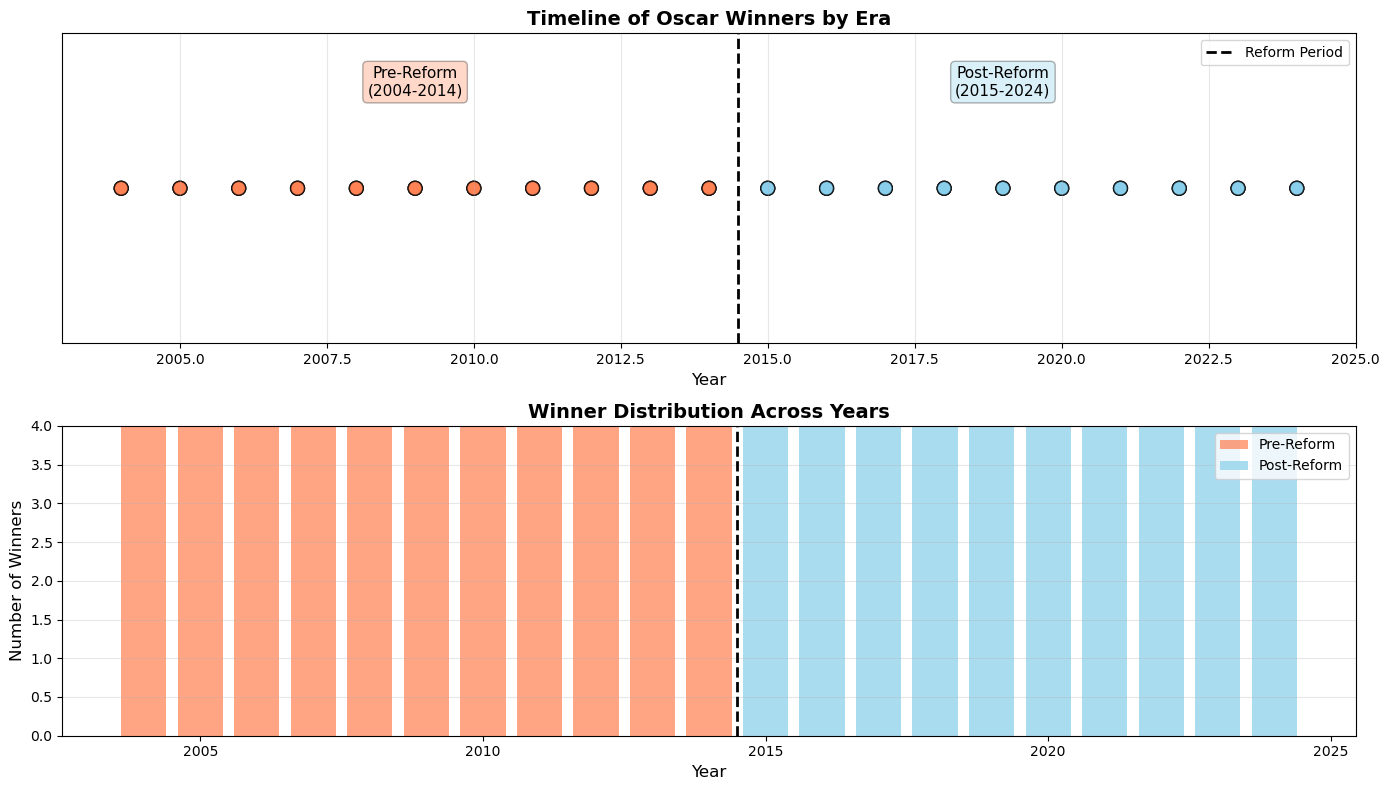

In [32]:
# Create timeline plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top plot: All winners over time
ax1 = axes[0]
years = winners_only['Year'].values
colors = ['coral' if era == 0 else 'skyblue' for era in sequence]

ax1.scatter(years, np.ones(len(years)), c=colors, s=100, alpha=0.6, edgecolors='black')
ax1.set_ylim(0.5, 1.5)
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.set_xlabel('Year', fontsize=12)
ax1.set_title('Timeline of Oscar Winners by Era', fontsize=14, fontweight='bold')
ax1.axvline(2014.5, color='black', linestyle='--', linewidth=2, label='Reform Period')
ax1.legend(loc='upper right')
ax1.grid(axis='x', alpha=0.3)

# Add era labels
ax1.text(2009, 1.3, 'Pre-Reform\n(2004-2014)', ha='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='coral', alpha=0.3))
ax1.text(2019, 1.3, 'Post-Reform\n(2015-2024)', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='skyblue', alpha=0.3))

# Bottom plot: Winners per year by era
ax2 = axes[1]
winners_by_year_era = winners_only.groupby(['Year', 'era']).size().unstack(fill_value=0)

if 0 in winners_by_year_era.columns and 1 in winners_by_year_era.columns:
    ax2.bar(winners_by_year_era.index, winners_by_year_era[0], 
            label='Pre-Reform', color='coral', alpha=0.7)
    ax2.bar(winners_by_year_era.index, winners_by_year_era[1], 
            bottom=winners_by_year_era[0],
            label='Post-Reform', color='skyblue', alpha=0.7)
else:
    # Handle case where one era might not exist in some years
    ax2.bar(winners_by_year_era.index, winners_by_year_era.sum(axis=1), 
            color='gray', alpha=0.7)

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Winners', fontsize=12)
ax2.set_title('Winner Distribution Across Years', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(2014.5, color='black', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print()

## Test 3: Logistic Regression

**Research Question:** Which factors predict whether a film wins an Academy Award? Does genre remain significant after controlling for film quality, popularity, and temporal factors?

In [33]:
# Use genres with sufficient sample size
logit_df = final_df[final_df['primary_genre'].isin(significant_genres)].copy()

print(f"Dataset for logistic regression: {len(logit_df)} nominations")
print(f"Winners: {logit_df['outcome'].sum()}")
print(f"Non-winners: {len(logit_df) - logit_df['outcome'].sum()}")
print()

# Check for missing values in predictor variables
print("Missing values in predictors:")
predictors = ['primary_genre', 'averageRating', 'log_votes', 'runtimeMinutes', 'era']
missing_counts = logit_df[predictors].isnull().sum()
print(missing_counts)
print()

# Drop rows with missing values in predictors
logit_df_clean = logit_df.dropna(subset=predictors).copy()
print(f"After removing missing values: {len(logit_df_clean)} observations")
print()

print("Converting numeric columns to proper types...")
logit_df_clean['averageRating'] = pd.to_numeric(logit_df_clean['averageRating'], errors='coerce')
logit_df_clean['log_votes'] = pd.to_numeric(logit_df_clean['log_votes'], errors='coerce')
logit_df_clean['runtimeMinutes'] = pd.to_numeric(logit_df_clean['runtimeMinutes'], errors='coerce')
logit_df_clean['era'] = pd.to_numeric(logit_df_clean['era'], errors='coerce')
logit_df_clean['outcome'] = pd.to_numeric(logit_df_clean['outcome'], errors='coerce')

# Drop any rows that became NaN after conversion
logit_df_clean = logit_df_clean.dropna(subset=predictors + ['outcome']).copy()
print(f"After ensuring numeric types: {len(logit_df_clean)} observations")
print()

Dataset for logistic regression: 482 nominations
Winners: 83
Non-winners: 399

Missing values in predictors:
primary_genre     0
averageRating     0
log_votes         0
runtimeMinutes    0
era               0
dtype: int64

After removing missing values: 482 observations

Converting numeric columns to proper types...
After ensuring numeric types: 482 observations



**Logistic Regression Assumptions:**
1. Binary outcome: outcome is 0 (lost) or 1 (won)
2. Independence: Each nomination is independent
3. Linearity: Continuous predictors have linear relationship with log-odds
4. No perfect multicollinearity: Check correlation between predictors
5. Large sample size: We have 482 observations

Correlation matrix of continuous predictors:
                averageRating  log_votes  runtimeMinutes    era
averageRating           1.000      0.663           0.091 -0.144
log_votes               0.663      1.000           0.164 -0.141
runtimeMinutes          0.091      0.164           1.000  0.188
era                    -0.144     -0.141           0.188  1.000



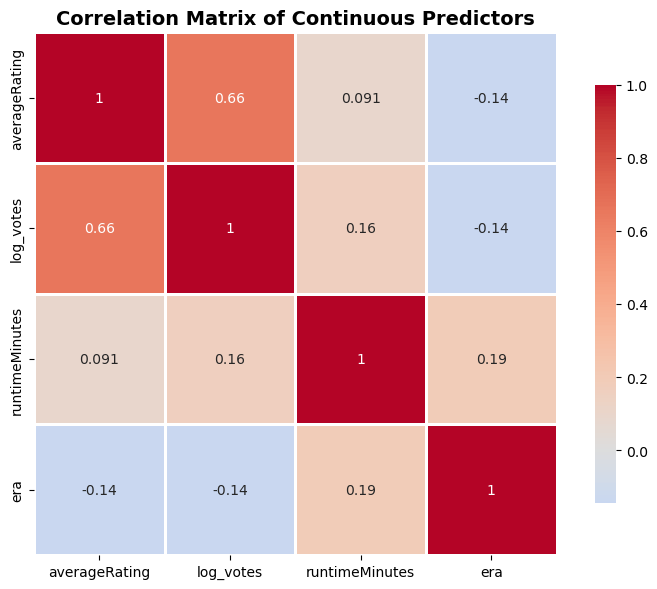

No severe multicollinearity detected (all correlations < 0.7)



In [34]:
# Check multicollinearity
print("Correlation matrix of continuous predictors:")
cont_predictors = ['averageRating', 'log_votes', 'runtimeMinutes', 'era']
corr_matrix = logit_df_clean[cont_predictors].corr()
print(corr_matrix.round(3))
print()

# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Continuous Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for high correlations (>0.7)
high_corr = (corr_matrix.abs() > 0.7) & (corr_matrix.abs() < 1.0)
if high_corr.any().any():
    print("Warning: High correlations detected (>0.7)")
    print("This may indicate multicollinearity issues")
else:
    print("No severe multicollinearity detected (all correlations < 0.7)")
print()

In [35]:
# Create dummy variables for genre (most common genre as reference)
reference_genre = logit_df_clean['primary_genre'].value_counts().index[0]
print(f"Reference category (baseline): {reference_genre}")
print()

# Create dummy variables, dropping the reference category
genre_dummies = pd.get_dummies(logit_df_clean['primary_genre'], prefix='genre', drop_first=False)

# Drop the reference genre column
if f'genre_{reference_genre}' in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(f'genre_{reference_genre}', axis=1)

print(f"Genre dummy variables created: {list(genre_dummies.columns)}")
print()

#Convert boolean dummies to integers (0/1)
genre_dummies = genre_dummies.astype(int)

# Combine all predictors (while ensuring all are numeric values)
X_predictors = pd.DataFrame({
    'averageRating': logit_df_clean['averageRating'].values,
    'log_votes': logit_df_clean['log_votes'].values,
    'runtimeMinutes': logit_df_clean['runtimeMinutes'].values,
    'era': logit_df_clean['era'].values
})

# Concatenate genre dummies
X = pd.concat([genre_dummies.reset_index(drop=True), X_predictors.reset_index(drop=True)], axis=1)

print("Checking all predictor types:")
print(X.dtypes)
print()

# Verify no object or bool types
problematic_types = (X.dtypes == 'object') | (X.dtypes == 'bool')
if problematic_types.any():
    print("ERROR: Some columns have object or bool type!")
    print("Columns with problematic types:", X.columns[problematic_types].tolist())
    print("\nAttempting to fix...")
    
    # Convert all to numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    print("After conversion:")
    print(X.dtypes)
    print()
else:
    print("All columns are numeric!")
    print()

# Get outcome variable
y = logit_df_clean['outcome'].values

# Add constant term
X_with_const = sm.add_constant(X, has_constant='add')

print("Final predictor matrix shape:", X_with_const.shape)
print("Final predictor types:")
print(X_with_const.dtypes.value_counts())
print()
print("Outcome vector shape:", y.shape)
print("Outcome type:", y.dtype)
print()

# Fit the model
print("Fitting logistic regression model...")
model = sm.Logit(y, X_with_const)
result = model.fit(disp=0)
print("Model fitted successfully!")
print()


Reference category (baseline): Drama

Genre dummy variables created: ['genre_Action', 'genre_Adventure', 'genre_Biography', 'genre_Comedy', 'genre_Crime']

Checking all predictor types:
genre_Action         int64
genre_Adventure      int64
genre_Biography      int64
genre_Comedy         int64
genre_Crime          int64
averageRating      float64
log_votes          float64
runtimeMinutes       int64
era                  int64
dtype: object

All columns are numeric!

Final predictor matrix shape: (482, 10)
Final predictor types:
int64      7
float64    3
Name: count, dtype: int64

Outcome vector shape: (482,)
Outcome type: int64

Fitting logistic regression model...
Model fitted successfully!



In [36]:
#Results and Interpretation
print(result.summary())
print()

# Extract coefficients, p-values, and confidence intervals
coef_df = pd.DataFrame({
    'Coefficient': result.params,
    'Std Error': result.bse,
    'z-value': result.tvalues,
    'P-value': result.pvalues,
    'Odds Ratio': np.exp(result.params),
    '95% CI Lower': np.exp(result.conf_int()[0]),
    '95% CI Upper': np.exp(result.conf_int()[1])
})

# Sort by odds ratio
coef_df_sorted = coef_df.drop('const', errors='ignore').sort_values('Odds Ratio', ascending=False)

print("\nCoefficient Interpretation (Odds Ratios):")
print("="*80)
print(coef_df_sorted.round(4))
print()

# Interpret significant predictors
print("\nInterpretation of Significant Predictors (α = 0.05):")
print("-"*80)

significant_vars = coef_df[coef_df['P-value'] < 0.05].drop('const', errors='ignore')

if len(significant_vars) == 0:
    print("No predictors are statistically significant at α = 0.05")
    print("This suggests that after controlling for all factors,")
    print("none individually predict winning probability.")
    print()
    print("Possible interpretations:")
    print("- The predictors may collectively explain winning (see Pseudo R²)")
    print("- Sample size may be insufficient for individual significance")
    print("- True effects may be small and harder to detect")
    print("- Other unmeasured factors may be more important")
else:
    for var, row in significant_vars.iterrows():
        odds_ratio = row['Odds Ratio']
        p_val = row['P-value']
        
        print(f"\n{var}:")
        print(f"  Odds Ratio: {odds_ratio:.3f} (p = {p_val:.4f})")
        
        if odds_ratio > 1:
            pct_change = (odds_ratio - 1) * 100
            print(f"POSITIVE effect: {pct_change:.1f}% increase in odds of winning")
            
            if 'genre_' in var:
                genre_name = var.replace('genre_', '')
                print(f"  Films in {genre_name} genre have {pct_change:.1f}% higher odds")
                print(f"  of winning compared to {reference_genre} (reference category)")
                print(f"  Interpretation: Being in the {genre_name} genre significantly")
                print(f"  increases Oscar win probability, even after controlling for")
                print(f"  film quality, popularity, and runtime.")
            elif var == 'averageRating':
                print(f"  Each 1-point increase in IMDb rating increases winning odds by {pct_change:.1f}%")
                print(f"  Interpretation: Higher-rated films are significantly more likely to win,")
                print(f"  suggesting quality metrics predict Academy preferences.")
            elif var == 'log_votes':
                print(f"  Higher vote counts (popularity) increase winning odds")
                print(f"  Interpretation: More popular films (measured by voting volume)")
                print(f"  have higher win probability, suggesting visibility matters.")
            elif var == 'runtimeMinutes':
                print(f"  Each additional minute increases winning odds by {pct_change:.1f}%")
                print(f"  Interpretation: Longer films have an advantage, possibly reflecting")
                print(f"  perceived epic scope or artistic ambition.")
            elif var == 'era':
                print(f"  Post-reform era (2015-2024) has {pct_change:.1f}% higher winning odds")
                print(f"  compared to pre-reform era (2004-2014)")
                print(f"  Interpretation: Academy reforms changed winning patterns,")
                print(f"  possibly due to diversified membership or shifting preferences.")
        else:
            pct_change = (1 - odds_ratio) * 100
            print(f"NEGATIVE effect: {pct_change:.1f}% decrease in odds of winning")
            
            if 'genre_' in var:
                genre_name = var.replace('genre_', '')
                print(f"  Films in {genre_name} genre have {pct_change:.1f}% lower odds")
                print(f"  of winning compared to {reference_genre} (reference category)")
                print(f"  Interpretation: Being in the {genre_name} genre significantly")
                print(f"  decreases Oscar win probability, suggesting genre bias against")
                print(f"  this category even after controlling for quality.")
            elif var == 'era':
                print(f"  Post-reform era (2015-2024) has {pct_change:.1f}% lower winning odds")
                print(f"  Interpretation: Despite reforms, later era shows lower win")
                print(f"  probability, possibly due to increased competition or changing standards.")

print()

# Model fit statistics
print("\nModel Fit Statistics:")
print("-"*80)
print(f"Log-Likelihood: {result.llf:.4f}")
print(f"AIC: {result.aic:.4f}")
print(f"BIC: {result.bic:.4f}")
print(f"Pseudo R-squared (McFadden): {result.prsquared:.4f}")
print()

# Interpret model fit
if result.prsquared < 0.2:
    print("Pseudo R^2 interpretation: Low explanatory power")
    print("  The model explains some variation but many factors remain unexplained.")
elif result.prsquared < 0.4:
    print("Pseudo R^2 interpretation: Moderate explanatory power")
    print("  The model captures meaningful patterns in Oscar winning.")
else:
    print("Pseudo R^2 interpretation: High explanatory power")
    print("  The model explains substantial variation in winning probability.")
print()

# Calculate accuracy on training data
predicted_probs = result.predict(X_with_const)
predicted_class = (predicted_probs > 0.5).astype(int)
accuracy = (predicted_class == y).mean()
print(f"Classification Accuracy: {accuracy*100:.2f}%")

# Baseline accuracy (always predict majority class)
baseline_accuracy = max((y == 0).mean(), (y == 1).mean())
print(f"Baseline Accuracy (majority class): {baseline_accuracy*100:.2f}%")

if accuracy > baseline_accuracy:
    improvement = (accuracy - baseline_accuracy) * 100
    print(f"Improvement over baseline: +{improvement:.2f} percentage points")
else:
    print("Model does not improve over baseline prediction.")
print()

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  482
Model:                          Logit   Df Residuals:                      472
Method:                           MLE   Df Model:                            9
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1370
Time:                        05:11:26   Log-Likelihood:                -191.09
converged:                       True   LL-Null:                       -221.41
Covariance Type:            nonrobust   LLR p-value:                 1.006e-09
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -16.2143      2.764     -5.866      0.000     -21.632     -10.797
genre_Action       -1.8450      0.672     -2.744      0.006      -3.163      -0.527
genre_Adventure    -2.0085      

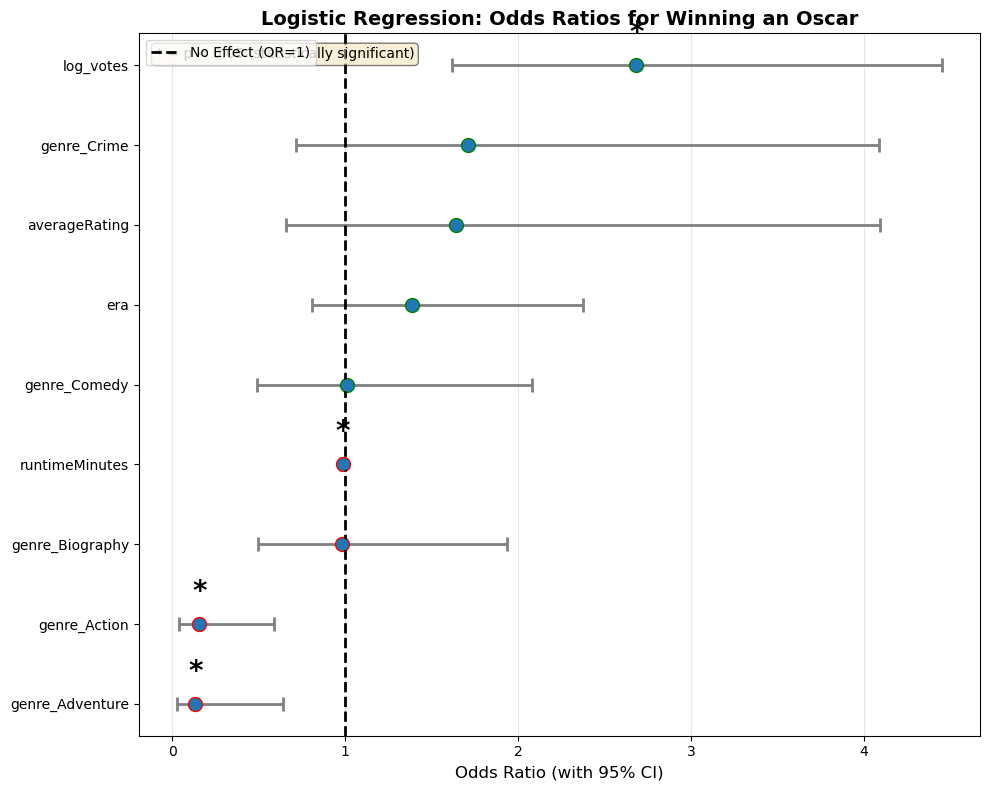

In [37]:
# Plot odds ratios with confidence intervals
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data (exclude intercept)
plot_data = coef_df.drop('const', errors='ignore').sort_values('Odds Ratio')

y_pos = np.arange(len(plot_data))

# Plot odds ratios as points with error bars
ax.errorbar(plot_data['Odds Ratio'], y_pos, 
            xerr=[plot_data['Odds Ratio'] - plot_data['95% CI Lower'],
                  plot_data['95% CI Upper'] - plot_data['Odds Ratio']],
            fmt='o', markersize=8, capsize=5, capthick=2,
            ecolor='gray', elinewidth=2)

# Color points by direction of effect
for i, (idx, row) in enumerate(plot_data.iterrows()):
    color = 'green' if row['Odds Ratio'] > 1 else 'red'
    ax.plot(row['Odds Ratio'], i, 'o', markersize=10, color=color)

    # Add asterisk for significant predictors
    if row['P-value'] < 0.05:
        ax.text(row['Odds Ratio'], i + 0.3, '*', 
                fontsize=20, ha='center', fontweight='bold')

# Reference line at 1 (no effect)
ax.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Effect (OR=1)')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=12)
ax.set_title('Logistic Regression: Odds Ratios for Winning an Oscar', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add text annotation
ax.text(0.02, 0.98, '* = p < 0.05 (statistically significant)',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

print()
